<a href="https://colab.research.google.com/github/3vergreene/PYTHON_PROJECTS/blob/main/ASSIGNMENT_(Problem_Set_on_Tutorial_on_Numpy%2C_Scipy_and_Astropy)_SALVADOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Submitted by Marielle Alexa Salvador


In [ ]:
!pip install jupyterquiz

In [ ]:
from jupyterquiz import display_quiz
from IPython.display import HTML

In [ ]:
git_path="https://raw.githubusercontent.com/aburousan/Intro2Astro/main/"

HTML('''<script>
  code_show=true;
  function code_toggle() {
    if (code_show){
        $('.cm-comment:contains(@hidden)').closest('div.input').hide();
    } else {
        $('.cm-comment:contains(@hidden)').closest('div.input').show();
    }
    code_show = !code_show
  }
  $( document ).ready(code_toggle);
</script>''')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

QUESTION 1

In [ ]:
def escape_velocity(G, M, R):
  """
  Calculates the escape velocity for a celestial body.

  Args:
    G: Gravitational constant (m^3 kg^-1 s^-2).
    M: Mass of the celestial body (kg).
    R: Radius of the celestial body (m).

  Returns:
    The escape velocity (m/s).
  """
  return np.sqrt(2 * G * M / R)

# Constants for Earth
G = 6.67430e-11  # m^3 kg^-1 s^-2
M_earth = 5.972e24  # kg
R_earth = 6.371e6  # m

# Calculate escape velocity for Earth
v_escape_earth = escape_velocity(G, M_earth, R_earth)

print(f"The escape velocity for Earth is: {v_escape_earth:.2f} m/s")

The escape velocity for Earth is: 11185.98 m/s


In [ ]:
display_quiz(git_path+"question1.json")

<IPython.core.display.Javascript object>

QUESTION 2

In [ ]:
def estimate_pi(n_samples=1000):
    x = np.random.rand(n_samples)
    y = np.random.rand(n_samples)
    distance = (x**2 + y**2)
    inside_circle = distance <= 1
    return 4 * np.sum(inside_circle) / n_samples

estimated_pi = estimate_pi()
print(f"Estimated value of pi using 1000 samples: {estimated_pi:.4f}")

Estimated value of pi using 1000 samples: 3.1960


QUESTION 3

In [ ]:
numbers = np.arange(10001)
mask = (numbers % 4 == 0) | (numbers % 7 == 0)
filtered_numbers = numbers[~mask]
total_sum = np.sum(filtered_numbers)

print(f"The sum of numbers from 0 to 10000 excluding those divisible by 4 or 7 is: {total_sum}")

The sum of numbers from 0 to 10000 excluding those divisible by 4 or 7 is: 32147142


In [ ]:
display_quiz(git_path+"question3.json", colors='fdsp')

<IPython.core.display.Javascript object>

QUESTION 4

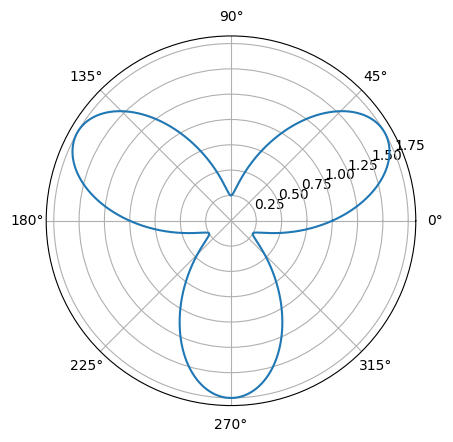

In [ ]:
theta=np.linspace(0,2*np.pi,100000)
r=1+((3/4)*np.sin(3*theta))
plt.polar(theta,r)
plt.show()

In [ ]:
from scipy.integrate import quad
def r(theta):
  return 1+(3/4)*np.sin(3*theta)

def integrand(theta):
  return 0.5*r(theta)**2

area, error=quad(integrand, 0, 2*np.pi)
print(f"This is the area enclosed by the polar curve: {area:.4f}")

This is the area enclosed by the polar curve: 4.0252


QUESTION 5

In [ ]:
from astropy import constants as const
from astropy import units as u
from scipy.integrate import solve_ivp
import numpy as np


G = const.G.value  # Gravitational constant in m^3 / (kg s^2)
M_sun = const.M_sun.value  # Mass of the Sun in kg
M_earth = const.M_earth.value # Mass of the Earth in kg

In [ ]:
def equations_of_motion(t, y, G, M_sun):
    """
    Defines the system of differential equations for Earth's motion around the Sun.

    Args:
        t: Time (s).
        y: A list containing the current state [x, y, vx, vy].
           x, y: position (m)
           vx, vy: velocity (m/s)
        G: Gravitational constant (m^3 kg^-1 s^-2).
        M_sun: Mass of the Sun (kg).

    Returns:
        A list containing the derivatives [vx, vy, ax, ay].
        vx, vy: velocity (m/s)
        ax, ay: acceleration (m/s^2)
    """
    x, y, vx, vy = y
    r_squared = x**2 + y**2
    r = np.sqrt(r_squared)
    ax = -G * M_sun * x / r**3
    ay = -G * M_sun * y / r**3
    return [vx, vy, ax, ay]

r_earth_orbit = 1.496e11
v_earth_orbit = np.sqrt(G * M_sun / r_earth_orbit)
initial_state = [r_earth_orbit, 0, 0, v_earth_orbit]
t_span = [0, 365.25 * 24 * 3600]


solution = solve_ivp(
    equations_of_motion,
    t_span,
    initial_state,
    args=(G, M_sun),
    dense_output=True,
    rtol=1e-9,
    atol=1e-9
)

t = solution.t
y = solution.y

x_pos = y[0, :]
y_pos = y[1, :]

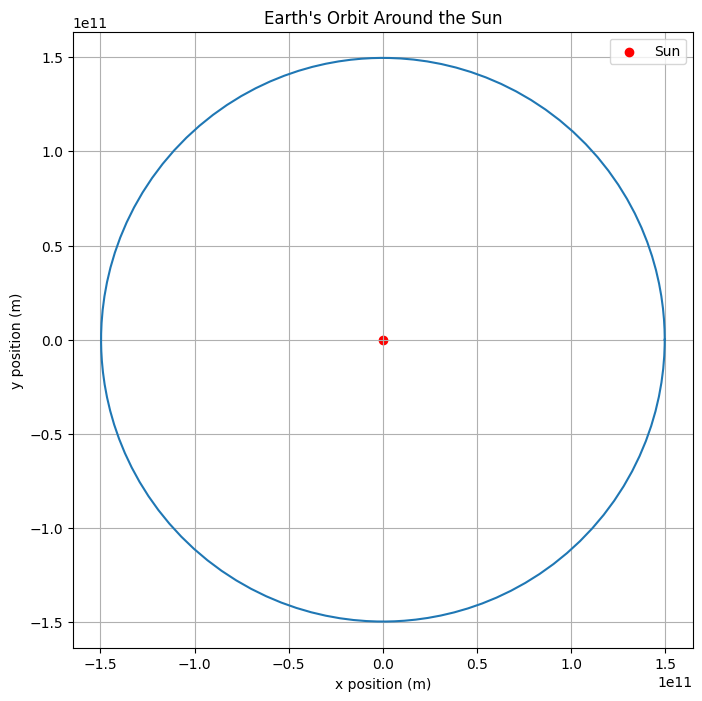

In [ ]:

plt.figure(figsize=(8, 8))
plt.plot(x_pos, y_pos)
plt.scatter(0, 0, color='red', label='Sun')
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.title("Earth's Orbit Around the Sun")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

QUESTION 6

In [ ]:
from scipy.optimize import curve_fit
import numpy as np
from astropy import constants as const

h=const.h.to('erg.s').value
c=const.c.to('cm/s').value
k=const.k_B.to('erg/K').value

data = np.loadtxt('/content/cmb_data.txt')
u=data[:,0]
f=data[:,1]

def I(u,T):
  n=2*h*c**2*u**3
  d=(h*c*u)/(k*T)
  return n/(np.exp(d)-1)

popt, pcov=curve_fit(I,u,f, p0=[2.7])

T_fit=popt[0]
T_err=np.sqrt(np.diag(pcov)[0])

print(f"This is the fitted temperature: {T_fit:.4f} k + {T_err:.4f} k")

This is the fitted temperature: 28180.8435 k + 17583.1824 k


QUESTION 7

In [ ]:
m=const.m_p
c=const.c
E_rest=m*c**2
E_J=E_rest.to('Joule')
E_MeV=E_J.to('MeV')
print(f"This is the rest energy of proton: {E_MeV}")
print(f"This is the rest energy of proton: {E_J}")

This is the rest energy of proton: 938.2720881604905 MeV
This is the rest energy of proton: 1.5032776159851256e-10 J


QUESTION 8

In [ ]:
from astropy.coordinates import SkyCoord, EarthLocation
import astropy.units as u

HG=SkyCoord.from_name('Betelgeuse')
print(HG)

del_hg=HG.dec
print(del_hg)
obs=EarthLocation(lon=88*u.deg+22*u.arcmin+23.88*u.arcsec,
                  lat=22*u.deg+29*u.arcmin+55.32*u.arcsec)

phi=obs.lat
print(phi)

<SkyCoord (ICRS): (ra, dec) in deg
    (88.79293899, 7.40706399)>
7d24m25.430382s
22d29m55.32s


In [ ]:
import math as m
h=m.acos(-m.tan(del_hg.rad)*m.tan(phi.rad))
print('h =', h)
T = (m.degrees(2*h)/360)*u.day
T_in_h=T.to(u.h)
print('T =', T_in_h)

h = 1.6246678039210198
T = 12.411547770061656 h


QUESTION 9

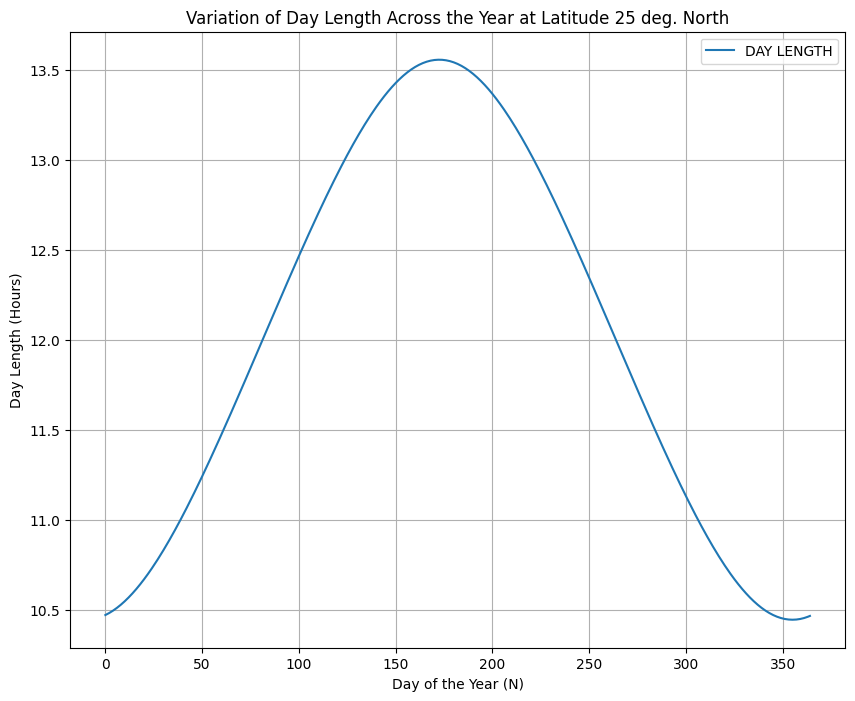

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

epsilon=np.radians(23.44)
days=np.arange(0,365)
phi=np.radians(25.0)
decl= -np.arcsin(np.sin(epsilon))*np.cos(2*np.pi*(days+10)/365)
cos_omega=-np.tan(phi)*np.tan(decl)
cos_omega=np.clip(cos_omega, -1,1)
day_length=2*np.degrees(np.arccos(cos_omega))/15

plt.figure(figsize=(10,8))
plt.plot(days, day_length, label='DAY LENGTH')
plt.xlabel('Day of the Year (N)')
plt.ylabel('Day Length (Hours)')
plt.title('Variation of Day Length Across the Year at Latitude 25 deg. North')
plt.grid(True)
plt.legend()
plt.show()

QUESTION 10

i cant find FITTS file